# Research Question 5 – CPI vs PPI and Potential Margin Expansion
#  How does the inflation gap between butter consumer prices and dairy producer prices evolve over time, and what might it indicate about potential margin expansion?

## 1. Imports

In [21]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Configuration

In [22]:
BASE_DIR = Path(".")

BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"

ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END = pd.Timestamp("2024-12-31")
MARGIN_EXPANSION_THRESHOLD = 5.0

## 3. Function: Convert Eurostat-JSON into a Dataframe

In [23]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
    """
    Convert a Eurostat-style JSON file into a tidy monthly DataFrame.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = pd.Series(data["dimension"]["time"]["category"]["index"], name="position")
    time_labels = pd.Series(data["dimension"]["time"]["category"]["label"], name="date_raw")
    values = pd.Series(data["value"], name=value_name)

    df = pd.concat([time_index, time_labels], axis=1).reset_index(drop=True)
    df["position"] = df["position"].astype(str)

    df = df.merge(
        values.rename_axis("position").reset_index(),
        on="position",
        how="left"
    )

    df["date"] = pd.to_datetime(
        df["date_raw"].str.replace("M", "-", regex=False),
        format="%Y-%m",
        errors="coerce"
    )

    df = df.drop(columns=["position", "date_raw"])
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df

def clean_time_series(
    df: pd.DataFrame,
    value_column: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    """
    Clean a monthly time series for analysis.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a date column and one value column.
    value_column : str
        Name of the value column.
    start_date : pd.Timestamp
        Lower bound of the analysis window.
    end_date : pd.Timestamp
        Upper bound of the analysis window.

    Returns
    -------
    pd.DataFrame
        Cleaned and filtered time series.
    """
     # Convert the Eurostat date format (e.g. "2020M01") into a proper datetime
    cleaned_df = df.copy()

     # Remove rows with missing dates / missing values
    cleaned_df = cleaned_df.dropna(subset=["date", value_column])
    cleaned_df = cleaned_df.drop_duplicates(subset=["date"], keep="last")
    cleaned_df = cleaned_df.sort_values("date").reset_index(drop=True)
    # Restrict the dataset to the selected analysis window
    cleaned_df = cleaned_df[
        (cleaned_df["date"] >= start_date) & (cleaned_df["date"] <= end_date)
    ].reset_index(drop=True)

    return cleaned_df


def build_margin_analysis_df(
    butter_df: pd.DataFrame,
    ppi_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Merge CPI and PPI data and create margin-related indicators.

    Parameters
    ----------
    butter_df : pd.DataFrame
        Cleaned butter CPI time series.
    ppi_df : pd.DataFrame
        Cleaned dairy PPI time series.

    Returns
    -------
    pd.DataFrame
        Merged DataFrame with YoY rates, gaps, and a potential
        margin expansion flag.
    """
    analysis_df = pd.merge(butter_df, ppi_df, on="date", how="inner")
    analysis_df = analysis_df.sort_values("date").reset_index(drop=True)

    # Calculate annual inflation rates for consumer and producer prices.
    analysis_df["butter_yoy_pct"] = analysis_df["butter_cpi"].pct_change(12) * 100
    analysis_df["dairy_ppi_yoy_pct"] = analysis_df["dairy_ppi"].pct_change(12) * 100

    # Inflation gap between consumer and producer prices.
    # A positive value means butter CPI inflation is higher than dairy PPI inflation.
    # This may indicate potential margin expansion along the supply chain.
    analysis_df["margin_gap"] = (
        analysis_df["butter_yoy_pct"] - analysis_df["dairy_ppi_yoy_pct"]
    )

    # Compare absolute index levels as an additional reference.
    analysis_df["cpi_ppi_gap"] = (
        analysis_df["butter_cpi"] - analysis_df["dairy_ppi"]
    )

    # Indicator variable: True if CPI inflation exceeds PPI inflation.
    # This does not prove margin expansions but highlights months where 
    # consumer prices increase faster than producer prices.
    analysis_df["margin_expansion_flag"] = (
        analysis_df["margin_gap"] > MARGIN_EXPANSION_THRESHOLD
    )

    return analysis_df


def print_data_quality_report(df: pd.DataFrame) -> None:
    """Print a compact data quality report for the merged dataset."""
    print("=" * 70)
    print("DATA QUALITY REPORT")
    print("=" * 70)
    print(f"Number of rows: {len(df)}")
    print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
    print("\nMissing values per column:")
    print(df.isna().sum())
    print(f"\nDuplicate dates: {df['date'].duplicated().sum()}")
    print("=" * 70)


def print_margin_summary(df: pd.DataFrame) -> None:
    """Print a short summary of the margin gap analysis."""
    valid_gap = df["margin_gap"].dropna()
    flagged_periods = df.loc[df["margin_expansion_flag"], ["date", "margin_gap"]]

    print("=" * 70)
    print("MARGIN EXPANSION SUMMARY")
    print("=" * 70)
    print(f"Average margin gap: {valid_gap.mean():.2f}")
    print(f"Maximum margin gap: {valid_gap.max():.2f}")
    print(f"Minimum margin gap: {valid_gap.min():.2f}")
    print(f"Potential margin expansion periods: {len(flagged_periods)}")

    # hier wirklich sinnvoll anders geht das nicht 
    if not flagged_periods.empty:
        print("\nTop flagged periods:")
        print(flagged_periods.sort_values("margin_gap", ascending=False).head(10))

    print("=" * 70)

## 4. Load and clean the JSON data

In [24]:
# Load the raw Eurostat datasets.
butter_raw_df = eurostat_json_to_df(BUTTER_FILE, "butter_cpi")
ppi_raw_df = eurostat_json_to_df(PPI_FILE, "dairy_ppi")

# Clean both time series within the selected analysis period.
butter_clean_df = clean_time_series(
    butter_raw_df,
    value_column="butter_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)
ppi_clean_df = clean_time_series(
    ppi_raw_df,
    value_column="dairy_ppi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

print("Butter cleaned shape:", butter_clean_df.shape)
print("PPI cleaned shape:", ppi_clean_df.shape)

butter_clean_df.head()

Butter cleaned shape: (60, 2)
PPI cleaned shape: (48, 2)


,butter_cpi,date
0,144.9,2020-01-01
1,143.3,2020-02-01
2,142.7,2020-03-01
3,142.5,2020-04-01
4,142.3,2020-05-01


## 5. Merge CPI and PPI and create analysis features

In [25]:
analysis_df = build_margin_analysis_df(butter_clean_df, ppi_clean_df)

print_data_quality_report(analysis_df)
analysis_df.head()

DATA QUALITY REPORT
Number of rows: 48
Date range: 2020-01-01 to 2023-12-01

Missing values per column:
butter_cpi                0
date                      0
dairy_ppi                 0
butter_yoy_pct           12
dairy_ppi_yoy_pct        12
margin_gap               12
cpi_ppi_gap               0
margin_expansion_flag     0
dtype: int64

Duplicate dates: 0


,butter_cpi,date,dairy_ppi,butter_yoy_pct,dairy_ppi_yoy_pct,margin_gap,cpi_ppi_gap,margin_expansion_flag
0,144.9,2020-01-01,111.4,NaN,NaN,NaN,33.5,False
1,143.3,2020-02-01,111.9,NaN,NaN,NaN,31.4,False
2,142.7,2020-03-01,111.4,NaN,NaN,NaN,31.3,False
3,142.5,2020-04-01,109.6,NaN,NaN,NaN,32.9,False
4,142.3,2020-05-01,108.1,NaN,NaN,NaN,34.2,False


## 6. Margin summary

In [26]:
print_margin_summary(analysis_df)

MARGIN EXPANSION SUMMARY
Average margin gap: -1.03
Maximum margin gap: 20.41
Minimum margin gap: -23.94
Potential margin expansion periods: 10

Top flagged periods:
         date  margin_gap
33 2022-10-01   20.410837
32 2022-09-01   19.355123
28 2022-05-01   15.165237
29 2022-06-01   15.102442
30 2022-07-01   13.971443
31 2022-08-01   13.349345
35 2022-12-01   13.103981
34 2022-11-01   11.235806
36 2023-01-01    6.939261
27 2022-04-01    6.396967


## 7. Visualization 1 – Dumbbell Plot of the Inflation Gap

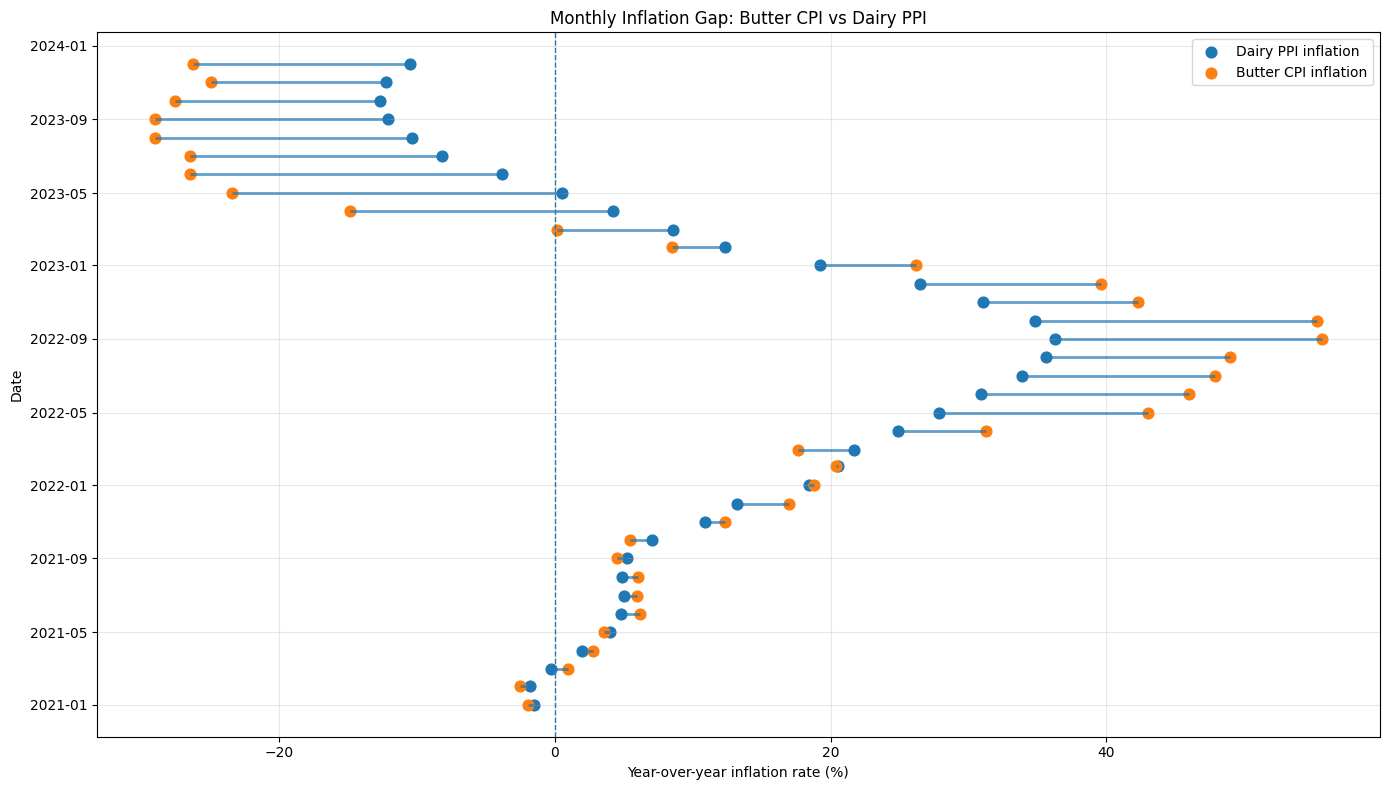

In [27]:
dumbbell_df = analysis_df.dropna(
    subset=["butter_yoy_pct", "dairy_ppi_yoy_pct"]
).copy()

plt.figure(figsize=(14, 8))

# Horizontal connection lines between PPI inflation and CPI inflation
plt.hlines(
    y=dumbbell_df["date"],
    xmin=dumbbell_df["dairy_ppi_yoy_pct"],
    xmax=dumbbell_df["butter_yoy_pct"],
    linewidth=2,
    alpha=0.7
)

# Left point: dairy PPI inflation
plt.scatter(
    dumbbell_df["dairy_ppi_yoy_pct"],
    dumbbell_df["date"],
    s=60,
    label="Dairy PPI inflation"
)

# Right point: butter CPI inflation
plt.scatter(
    dumbbell_df["butter_yoy_pct"],
    dumbbell_df["date"],
    s=60,
    label="Butter CPI inflation"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Monthly Inflation Gap: Butter CPI vs Dairy PPI")
plt.xlabel("Year-over-year inflation rate (%)")
plt.ylabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Visualization 2 – Heatmap of the Margin Gap 

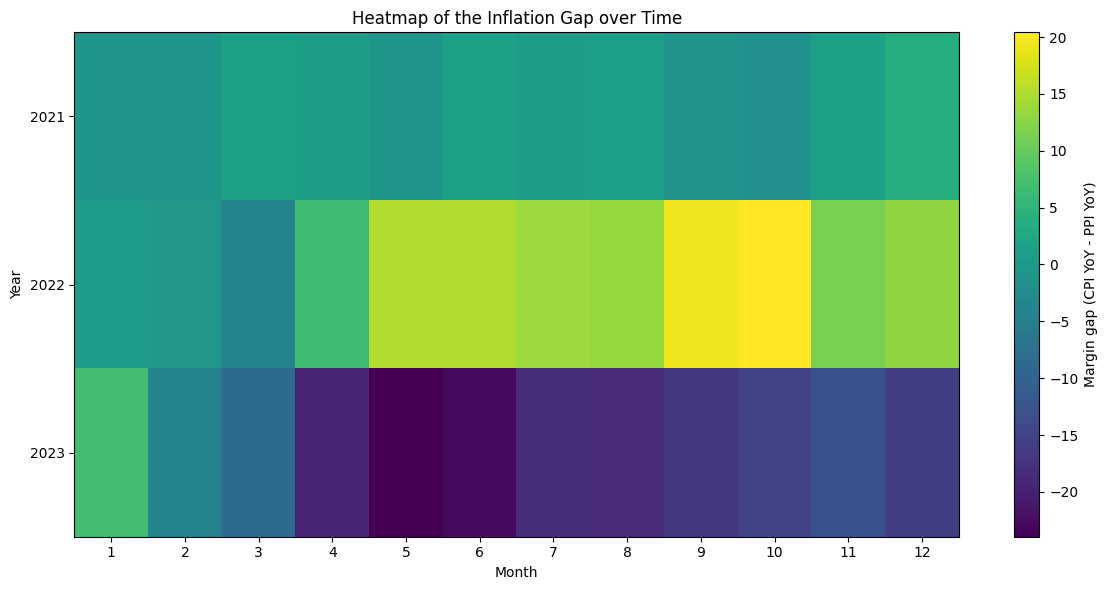

In [28]:
heatmap_df = analysis_df.dropna(subset=["margin_gap"]).copy()

# Extract year and month for the matrix layout
heatmap_df["year"] = heatmap_df["date"].dt.year
heatmap_df["month"] = heatmap_df["date"].dt.month

# Create pivot table: rows = year, columns = month, values = margin gap
heatmap_matrix = heatmap_df.pivot_table(
    index="year",
    columns="month",
    values="margin_gap"
)

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_matrix, aspect="auto")

plt.colorbar(label="Margin gap (CPI YoY - PPI YoY)")
plt.title("Heatmap of the Inflation Gap over Time")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=range(len(heatmap_matrix.columns)),
    labels=heatmap_matrix.columns
)
plt.yticks(
    ticks=range(len(heatmap_matrix.index)),
    labels=heatmap_matrix.index
)
plt.tight_layout()
plt.show()

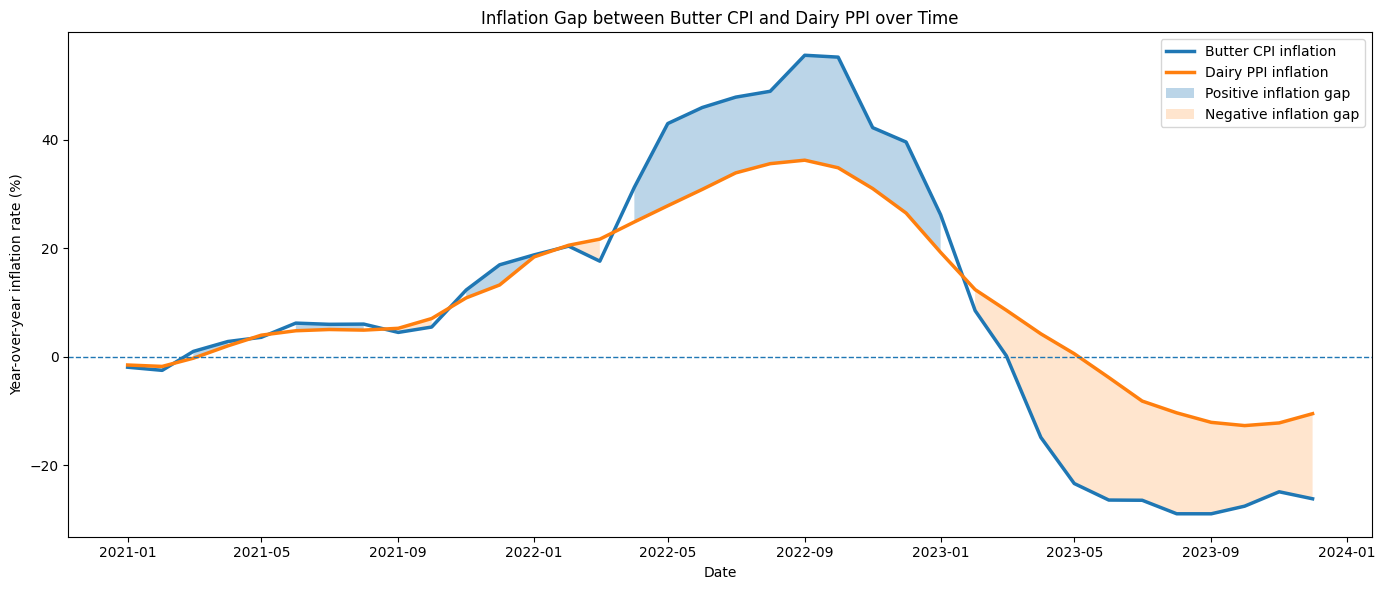

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    analysis_df["date"],
    analysis_df["butter_yoy_pct"],
    label="Butter CPI inflation",
    linewidth=2.5
)

plt.plot(
    analysis_df["date"],
    analysis_df["dairy_ppi_yoy_pct"],
    label="Dairy PPI inflation",
    linewidth=2.5
)

plt.fill_between(
    analysis_df["date"],
    analysis_df["butter_yoy_pct"],
    analysis_df["dairy_ppi_yoy_pct"],
    where=(analysis_df["butter_yoy_pct"] >= analysis_df["dairy_ppi_yoy_pct"]),
    alpha=0.3,
    label="Positive inflation gap"
)

plt.fill_between(
    analysis_df["date"],
    analysis_df["butter_yoy_pct"],
    analysis_df["dairy_ppi_yoy_pct"],
    where=(analysis_df["butter_yoy_pct"] < analysis_df["dairy_ppi_yoy_pct"]),
    alpha=0.2,
    label="Negative inflation gap"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Inflation Gap between Butter CPI and Dairy PPI over Time")
plt.xlabel("Date")
plt.ylabel("Year-over-year inflation rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# wichtigste dateien für csv website 
rq5_export_df = analysis_df[
    [
        "date",
        "butter_yoy_pct",
        "dairy_ppi_yoy_pct",
        "margin_gap",
        "margin_expansion_flag"
    ]
].dropna(
    subset=["butter_yoy_pct", "dairy_ppi_yoy_pct"]
).copy()

In [31]:
from pathlib import Path

output_path = Path("/Users/ceydadut/Desktop/DataScienceProject/DataScienceProject/website/data/rq5_data.csv")
rq5_export_df.to_csv(output_path, index=False)